In [17]:
import os, torch
import numpy as np
from TrainingTools import ABCDModel, _batched_scores, _plot_roc_curves

In [ ]:
tag = "run3_2L_2FJ"
signal = "c2v1p5_c3_1p0" # c2v1p0_c3_1p0, c2v1p0_c3_10p0, c2v1p5_c3_1p0
dataset_dir = f"260916_dataset/{signal}"
best_model_path = f"models/{tag}_best_model.pt"
os.makedirs("models", exist_ok=True)

train_dataset = torch.load(f"{dataset_dir}/{tag}_train.pt", weights_only=False)
valid_dataset = torch.load(f"{dataset_dir}/{tag}_valid.pt", weights_only=False)
print(train_dataset)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4096, shuffle=True, pin_memory=True, num_workers=4)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=4096, shuffle=False, pin_memory=True, num_workers=4)
print(train_loader)

In [19]:
model = ABCDModel(
        input_size    = train_dataset[0][0].shape[0],
        hidden_layers = [64, 32, 16],
        learning_rate = 0.001,
        bce_weight    = 1.0,
        disco_lambda  = 10.0,
        flavor        = 'single',
        use_batchnorm = True,
        dropout       = 0.2,
        weight_decay  = 0.01,
        label_smoothing = 0.0,
        use_lr_scheduler  = True, # LR = Learning Rate
        lr_scheduler_patience = 5,
        lr_scheduler_factor = 0.5,
        lr_scheduler_min_lr = 1e-6,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # uses GPU
print(device)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=model.learning_rate,
    weight_decay=model.weight_decay,
)

scheduler = None
if model.use_lr_scheduler:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=model.lr_scheduler_factor,
        patience=model.lr_scheduler_patience,
        min_lr=model.lr_scheduler_min_lr,
    )

cuda


In [20]:
max_epochs = 100
early_stopping_patience = 20
best_val_loss = float("inf")
epochs_since_best = 0
for epoch in range(max_epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = tuple(x.to(device) for x in batch)
        optimizer.zero_grad()
        loss, bce, disco, _ = model.compute_loss(batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ---------------- VAL ----------------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            batch = tuple(x.to(device) for x in batch)
            loss, bce, disco, _ = model.compute_loss(batch)
            val_loss += loss.item()
    val_loss /= len(valid_loader)

    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_since_best = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model to {best_model_path}")
    else:
        epochs_since_best += 1

    # ---------------- scheduler ----------------
    if scheduler is not None:
        scheduler.step(val_loss)

    # ---------------- early termination ----------------
    if epochs_since_best >= early_stopping_patience:
        print(f"No improvement for {early_stopping_patience} epochs, stopping at epoch {epoch}. Best val={best_val_loss:.4f}")
        break

Epoch 0: train=0.6684, val=0.6667
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 1: train=0.5821, val=0.5635
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 2: train=0.5458, val=0.5184
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 3: train=0.5138, val=0.4907
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 4: train=0.4927, val=0.4707
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 5: train=0.4665, val=0.4535
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 6: train=0.4552, val=0.4367
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 7: train=0.4429, val=0.4216
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 8: train=0.4328, val=0.4096
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 9: train=0.4299, val=0.4052
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 10: train=0.4081, val=0.3933
Saved best model to models/run3_2L_2FJ_best_model.pt
Epoch 11: train=0.4009, val=0.3793
Saved b

/tmp/ipykernel_56/473323558.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


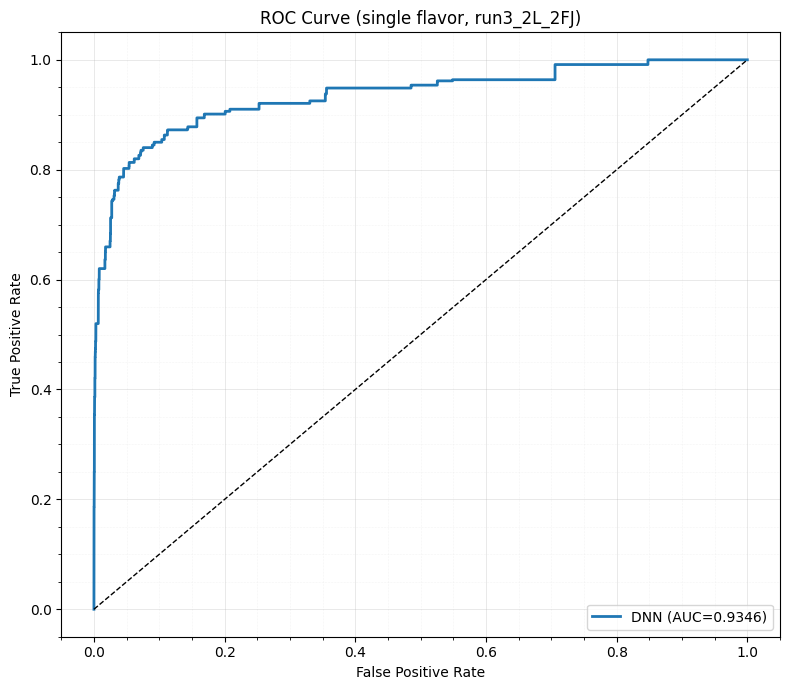

In [21]:
# Evaluate the best model
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()
score_0 = _batched_scores(model, valid_loader, flavor='single', device=device)[0]

# valid_loader is shuffle=False, so labels/weights line up with the scores above
full_inference_data = {
    "label": np.concatenate([y.numpy() for _, _, y, _ in valid_loader]),
    "weight": np.concatenate([w.numpy() for _, _, _, w in valid_loader]),
    "dnn_score": score_0,
}
os.makedirs("roc_curve", exist_ok=True)
_plot_roc_curves(full_inference_data, flavor='single', output_path=f"roc_curve/{tag}.png", tag=tag)